In [20]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning') # Annoying hanging H-atom warnings

df = pd.read_csv('../data/solubility-dataset.csv')

# Conformational Flexibility

Molecules can rotate around their bonds and form different 3D shapes called conformers. This affects solubility and is particularly important in drug design.

AQSolDB stores SMILES strings (like 'CCO' for ethanol) for each of its molecules, which allows us to find a nice toy molecule with some rotatable bonds, (ibuprofen). The more rotatble bonds in a molecule, the more configurations it can exist in:

In [21]:
ibuprofen_smiles = "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O"
ibuprofen_solubility = df[df['SMILES'] == ibuprofen_smiles]['Solubility'].iloc[0] if 'Solubility' in df.columns and (df['SMILES'] == ibuprofen_smiles).any() else 'Unknown'
print(f'Chosen molecule SMILES: {ibuprofen_smiles}')
print(f'Solubility: {ibuprofen_solubility}')
molecule = Chem.MolFromSmiles(ibuprofen_smiles)


Chosen molecule SMILES: CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O
Solubility: Unknown


A *conformer* is an 3D shape instance that the molecule can fall into. These can be created with RDKit's ETKD create 10 conformers, and low-energy states can be found by reducing the MMFF (Merck Molecular Force Field).

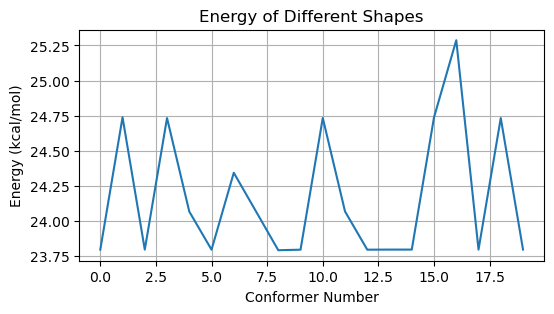

In [24]:
molecule = Chem.AddHs(molecule) # Add hydrogens (needed for 3D structures)
AllChem.EmbedMultipleConfs(molecule, numConfs=20, params=AllChem.ETKDG()) # 10 conformers

energies = []
for conf_id in range(20):
    props = AllChem.MMFFGetMoleculeProperties(molecule)
    force_field = AllChem.MMFFGetMoleculeForceField(molecule, props, confId=conf_id)
    if force_field is not None:
        force_field.Minimize()  # Adjust to lowest energy
        energies.append(force_field.CalcEnergy())
    else:
        energies.append(float('nan'))  # Invalid conformers

plt.figure(figsize=(6, 3))
plt.plot(range(len(energies)), energies)
plt.xlabel('Conformer Number')
plt.ylabel('Energy (kcal/mol)')
plt.title('Energy of Different Shapes')
plt.grid(True)
plt.show()

In drug design, the lowest-energy shape might be the one that best fits a protein's binding site. The lowest and highest energy states are visualised below:

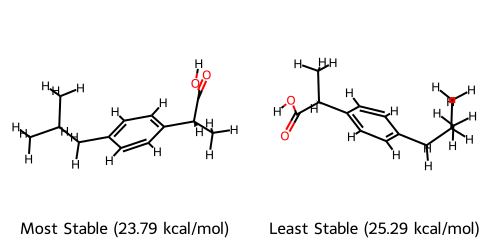

In [25]:
valid_energies = [e for e in energies if not pd.isna(e)]  # Ignore invalid
lowest_energy_idx = energies.index(min(valid_energies))
highest_energy_idx = energies.index(max(valid_energies))

conformer_ids = [lowest_energy_idx, highest_energy_idx]
labels = [f'Most Stable ({min(valid_energies):.2f} kcal/mol)', f'Least Stable ({max(valid_energies):.2f} kcal/mol)']
Draw.MolsToGridImage([molecule, molecule], molsPerRow=2, subImgSize=(250, 250), legends=labels, confIds=conformer_ids)
